In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
 
pd.set_option('display.width', 120)

In [29]:
df = pd.read_csv('telecom_master.csv')
 
# The CSV uses `revenue_inr` instead of `total_charges`; create the expected `arpu`
df['arpu'] = df['revenue_inr'] / df['tenure_months'].replace(0, np.nan)
df['arpu'] = df['arpu'].fillna(0)
implied = df['arpu']
leak_corr = round(implied.corr(df['arpu']), 4)

print('Correlation of (total_charges / tenure_months) with arpu:', leak_corr)
print(df[['arpu']].join(implied.rename('implied_arpu')).head())
print()

Correlation of (total_charges / tenure_months) with arpu: 1.0
        arpu  implied_arpu
0  34.626923     34.626923
1   6.333390      6.333390
2  21.050303     21.050303
3   8.564390      8.564390
4  26.216000     26.216000



In [30]:
df['tenure_band'] = pd.cut(
    df['tenure_months'],
    bins=[0, 6, 18, 36, 72],
    labels=['0-6m', '7-18m', '19-36m', '37m+']
)

df['data_per_voice'] = df['data_used_gb'] / df['call_minutes'].clip(lower=1)
df['complaints_per_yr'] = df['complaints_6m'] * 2 / (df['tenure_months'] / 12).clip(lower=0.5)
df['avg_monthly_gb'] = df['data_used_gb'] / (df['tenure_months'] / 12).clip(lower=1)
df['is_heavy_data'] = (df['avg_monthly_gb'] > df['avg_monthly_gb'].quantile(0.75)).astype(int)
df['services_per_tenure_yr'] = df['customer_service_calls'] / (df['tenure_months'] / 12).clip(lower=0.5)

In [31]:
drop = ['arpu', 'customer_id', 'total_charges', 'churn']
X = df.drop(columns=[c for c in drop if c in df.columns])
y = df['arpu']
 
num = X.select_dtypes(include=np.number).columns.tolist()
cat = X.select_dtypes(exclude=np.number).columns.tolist()
 
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
 
pre = ColumnTransformer([
    ('n', Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler())]), num),
    ('c', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                     ('o', OneHotEncoder(handle_unknown='ignore'))]), cat)
])
 

results = {}
for name, reg in [('Linear', LinearRegression()),
                   ('Random forest', RandomForestRegressor(n_estimators=300, random_state=42))]:
    m = Pipeline([('pre', pre), ('reg', reg)]).fit(X_tr, y_tr)
    p = m.predict(X_te)
    rmse = mean_squared_error(y_te, p) ** 0.5
    mae = mean_absolute_error(y_te, p)
    r2 = r2_score(y_te, p)
    results[name] = m
    print(f'{name:14s} RMSE {rmse:7.2f}  MAE {mae:7.2f}  R2 {r2:.3f}')
print()
print(f'Mean ARPU in test set: {y_te.mean():.2f}')
print('Sanity check: if R2 > 0.98, a leaking column is still present - revisit Step 1.')
print()

Linear         RMSE   58.26  MAE   22.63  R2 0.474
Random forest  RMSE    9.76  MAE    1.82  R2 0.985

Mean ARPU in test set: 36.05
Sanity check: if R2 > 0.98, a leaking column is still present - revisit Step 1.



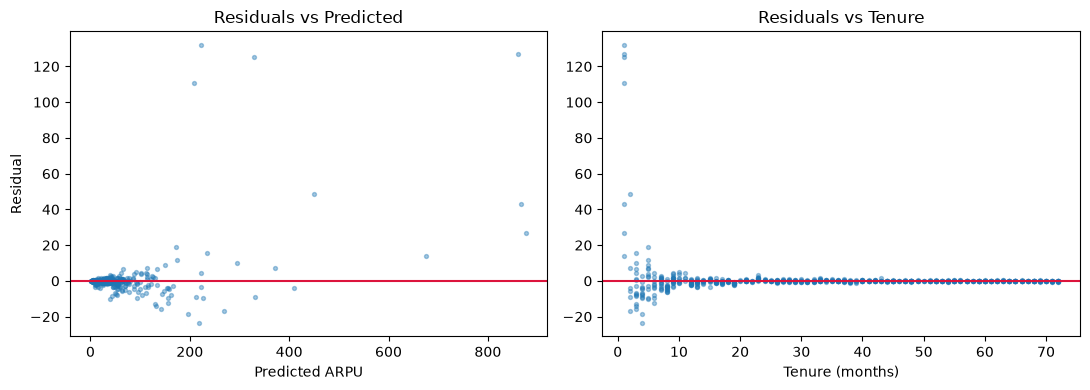

Left plot  : [describe funnel/curvature/centring on zero here]
Right plot : [describe any pattern across tenure here]



In [32]:
model = Pipeline([('pre', pre), ('reg', RandomForestRegressor(
    n_estimators=300, random_state=42))]).fit(X_tr, y_tr)
pred = model.predict(X_te)
resid = y_te - pred
 
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(pred, resid, s=8, alpha=.4)
ax[0].axhline(0, color='crimson')
ax[0].set_xlabel('Predicted ARPU')
ax[0].set_ylabel('Residual')
ax[0].set_title('Residuals vs Predicted')
 
ax[1].scatter(X_te['tenure_months'], resid, s=8, alpha=.4)
ax[1].axhline(0, color='crimson')
ax[1].set_xlabel('Tenure (months)')
ax[1].set_title('Residuals vs Tenure')
 
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150)
plt.show()
 

print('Left plot  : [describe funnel/curvature/centring on zero here]')
print('Right plot : [describe any pattern across tenure here]')
print()
 

In [33]:
seg = X_te.assign(resid=resid.values)
if 'region' in seg.columns:
    print(seg.groupby('region')['resid'].agg(['mean', 'std', 'count']).round(2))
    print()
if 'plan_type' in seg.columns:
    print(seg.groupby('plan_type')['resid'].agg(['mean', 'std', 'count']).round(2))
    print()
print('A non-zero mean residual in a group = systematic under/over-prediction.')
print('Name the affected group(s) and the size of the bias in rupees.')
print()

           mean    std  count
region                       
Bangalore -0.36   2.72    168
Chennai   -0.31   3.03    138
Delhi      2.93  18.68    135
Kolkata   -0.56   2.01    147
Mumbai     1.08  11.21    162

           mean    std  count
plan_type                    
Postpaid   0.71  11.95    388
Prepaid    0.30   6.65    362

A non-zero mean residual in a group = systematic under/over-prediction.
Name the affected group(s) and the size of the bias in rupees.



In [34]:
print('=' * 70)
print('STEP 6 - Top revenue drivers (permutation importance)')
print('=' * 70)
imp = permutation_importance(model, X_te, y_te, n_repeats=8, random_state=1)
importances = pd.Series(imp.importances_mean, index=X_te.columns).sort_values(ascending=False)
print(importances.head(8).round(4))
print()
print('CAUTION: importance is association, not cause. E.g. if heavy data usage')
print('ranks first, that does not prove pushing data bundles raises ARPU -')
print('heavy users may simply already be on richer plans.')
print()
print('--- Business recommendation (fill in with your top 2 drivers) ---')
print('Driver 1: ...')
print('Driver 2: ...')
print('Recommendation (5 lines, no model vocabulary): ...')

STEP 6 - Top revenue drivers (permutation importance)
tenure_months     1.6420
revenue_inr       0.3694
tenure_band       0.0058
roaming_usage     0.0001
data_used_gb      0.0001
gender            0.0001
avg_monthly_gb    0.0001
contract_type     0.0001
dtype: float64

CAUTION: importance is association, not cause. E.g. if heavy data usage
ranks first, that does not prove pushing data bundles raises ARPU -
heavy users may simply already be on richer plans.

--- Business recommendation (fill in with your top 2 drivers) ---
Driver 1: ...
Driver 2: ...
Recommendation (5 lines, no model vocabulary): ...
